# Synent Technologies Data Science Internship - Task 3:Netflix Titles Exploratory Data Analysis (EDA)
**Intern: [Rishabh Sakariya]**

## Project Overview
This notebook performs an Exploratory Data Analysis (EDA) on the Netflix Titles dataset. The goal is to uncover insights into the types of content available on Netflix, identify trends, and understand various attributes like genre distribution, top creators, and content evolution over time.

### Dataset
The dataset `netflix_titles.csv` contains information about movies and TV shows available on Netflix, including details like title, director, cast, country, release year, rating, duration, and listed categories.

## A. Data Loading

### A.1. Import Libraries
We start by importing the necessary Python libraries for data manipulation, analysis, and visualization.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot styles
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### A.2. Load Dataset
Load the `netflix_titles.csv` file into a pandas DataFrame.

In [ ]:
# Load the dataset
df = pd.read_csv('/content/netflix_titles.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


### A.3. Display First 5 Rows
View the initial rows of the DataFrame to get a glimpse of the data structure and content.

In [ ]:
# Display the first 5 rows of the DataFrame
display(df.head())

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### A.4. Display Dataset Shape
Check the number of rows and columns in the dataset.

In [ ]:
# Display the shape of the dataset (rows, columns)
print(f"Dataset shape: {df.shape}")

Dataset shape: (8807, 12)


### A.5. Display Columns
List all column names present in the DataFrame.

In [ ]:
# Display all column names
print("Dataset columns:")
for col in df.columns:
    print(f"- {col}")

Dataset columns:
- show_id
- type
- title
- director
- cast
- country
- date_added
- release_year
- rating
- duration
- listed_in
- description


### A.6. Display Dataset Information
Get a concise summary of the DataFrame, including data types, non-null values, and memory usage.

In [ ]:
# Display dataset information
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## B. Data Cleaning

### B.1. Check Missing Values
Identify columns with missing values and count them to understand the extent of missing data.

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing values in each column:")
display(missing_values)

Missing values in each column:


,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3


### B.2. Visualize Missing Values
Use a heatmap to visually represent the missing data across the DataFrame. This helps to quickly identify patterns of missingness.

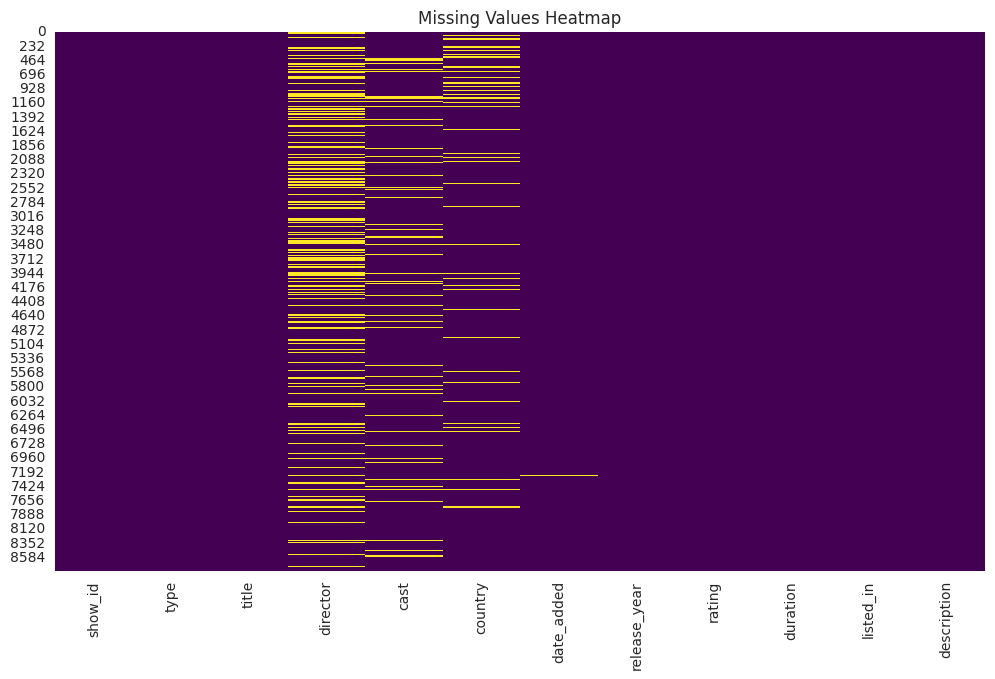

In [ ]:
# Visualize missing values using a heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### B.3. Handle Missing Values
Address missing values in specific columns:
- `director`: Fill with 'Unknown Director'.
- `cast`: Fill with 'Unknown Cast'.
- `country`: Fill with the mode (most frequent country).
- `rating`: Fill with the mode (most frequent rating).
- `date_added`: Drop rows where 'date_added' is missing, as it's crucial for time-series analysis.
- `duration`: Drop rows where 'duration' is missing. (Although 'duration' has very few missing values and is important for content analysis).

In [ ]:
# Handle missing values

# Fill 'director' and 'cast' with 'Unknown'
df['director'].fillna('Unknown Director', inplace=True)
df['cast'].fillna('Unknown Cast', inplace=True)

# Fill 'country' and 'rating' with their respective modes
# The mode might return multiple values if there's a tie, so we take the first one.
df['country'].fillna(df['country'].mode()[0], inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)

# Drop rows where 'date_added' is missing. This column is important for trend analysis.
df.dropna(subset=['date_added'], inplace=True)

# Drop rows where 'duration' is missing
df.dropna(subset=['duration'], inplace=True)

print("Missing values handled for 'director', 'cast', 'country', 'rating', 'date_added', and 'duration'.")

Missing values handled for 'director', 'cast', 'country', 'rating', 'date_added', and 'duration'.


/tmp/ipykernel_834/2491024928.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown Director', inplace=True)
/tmp/ipykernel_834/2491024928.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

### B.4. Verify Cleaned Dataset
Re-check for missing values after handling them to ensure the cleaning process was successful.

In [ ]:
import re

# Strip leading/trailing whitespace from 'date_added' column to handle inconsistencies like ' August 4, 2017'
df['date_added'] = df['date_added'].astype(str).str.strip()

# Convert 'date_added' to datetime objects, using mixed format inference and coercing errors to NaT
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

# Drop rows where 'date_added' is NaT (unparseable dates) to ensure clean date data for further analysis
df.dropna(subset=['date_added'], inplace=True)

# Extract 'year_added' and 'month_added' for further analysis
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Create duration_minutes column for movies
# Use .str.extract to get the numeric part and convert to float
df['duration_minutes'] = df[df['type'] == 'Movie']['duration'].str.extract('(\\d+)\\s*min')[0].astype(float)

# Create duration_seasons column for TV shows
# Use .str.extract to get the numeric part and convert to float
df['duration_seasons'] = df[df['type'] == 'TV Show']['duration'].str.extract('(\\d+)\\s*Season')[0].astype(float)

# Drop the 'duration_numeric' column if it exists, as it's no longer needed
if 'duration_numeric' in df.columns:
    df.drop(columns=['duration_numeric'], inplace=True)

# Verify the cleaned dataset for missing values AFTER all processing
missing_values_after_cleaning = df.isnull().sum()
print("Missing values in each column after cleaning:")
display(missing_values_after_cleaning[missing_values_after_cleaning > 0])

# Display the updated info and head to verify new columns and types
print("\nUpdated Dataset Information:")
df.info()
print("\nFirst 5 rows after adding 'year_added', 'month_added' and processing duration:")
display(df.head())

Missing values in each column after cleaning:


,0
duration_minutes,2666
duration_seasons,6128



Updated Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 8794 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8794 non-null   object        
 1   type              8794 non-null   object        
 2   title             8794 non-null   object        
 3   director          8794 non-null   object        
 4   cast              8794 non-null   object        
 5   country           8794 non-null   object        
 6   date_added        8794 non-null   datetime64[ns]
 7   release_year      8794 non-null   int64         
 8   rating            8794 non-null   object        
 9   duration          8794 non-null   object        
 10  listed_in         8794 non-null   object        
 11  description       8794 non-null   object        
 12  year_added        8794 non-null   int32         
 13  month_added       8794 non-null   object        
 14 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_minutes,duration_seasons
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown Cast,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September,90.0,NaN
1,s2,TV Show,Blood & Water,Unknown Director,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September,NaN,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",United States,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September,NaN,1.0
3,s4,TV Show,Jailbirds New Orleans,Unknown Director,Unknown Cast,United States,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September,NaN,1.0
4,s5,TV Show,Kota Factory,Unknown Director,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September,NaN,2.0


## C. Exploratory Data Analysis (EDA)

### C.1. Generate Summary Statistics
Obtain descriptive statistics for numerical columns, providing insights into central tendency, dispersion, and shape of the distribution.

In [ ]:
# Generate summary statistics for numerical columns
print("Summary Statistics:")
display(df.describe())

Summary Statistics:


,date_added,release_year,year_added,duration_numeric,duration_minutes,duration_seasons
count,8794,8794.000000,8794.000000,6128.000000,6128.000000,0.0
mean,2019-05-17 13:29:44.034568960,2014.183534,2018.872754,99.577187,99.577187,NaN
min,2008-01-01 00:00:00,1925.000000,2008.000000,3.000000,3.000000,NaN
25%,2018-04-06 00:00:00,2013.000000,2018.000000,87.000000,87.000000,NaN
50%,2019-07-02 00:00:00,2017.000000,2019.000000,98.000000,98.000000,NaN
75%,2020-08-19 00:00:00,2019.000000,2020.000000,114.000000,114.000000,NaN
max,2021-09-25 00:00:00,2021.000000,2021.000000,312.000000,312.000000,NaN
std,NaN,8.823527,1.573789,28.290593,28.290593,NaN


### C.2. Movies vs. TV Shows Count Plot
Visualize the distribution of content types (Movies vs. TV Shows) on Netflix.

/tmp/ipykernel_834/3060833182.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='viridis')


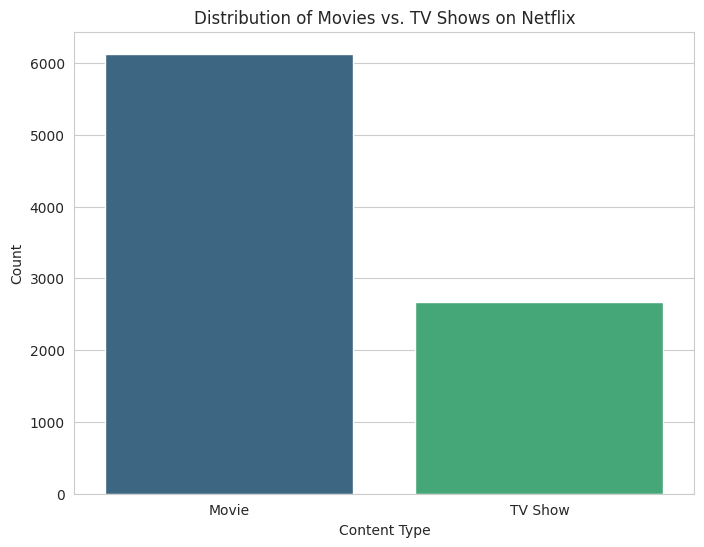

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Distribution of Movies vs. TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

**Insight:** Movies significantly outnumber TV shows on Netflix, indicating a higher volume of film content available on the platform.

### C.3. Content Rating Distribution
Analyze the distribution of content ratings to understand the target audience for Netflix content.

/tmp/ipykernel_834/203638311.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='magma')


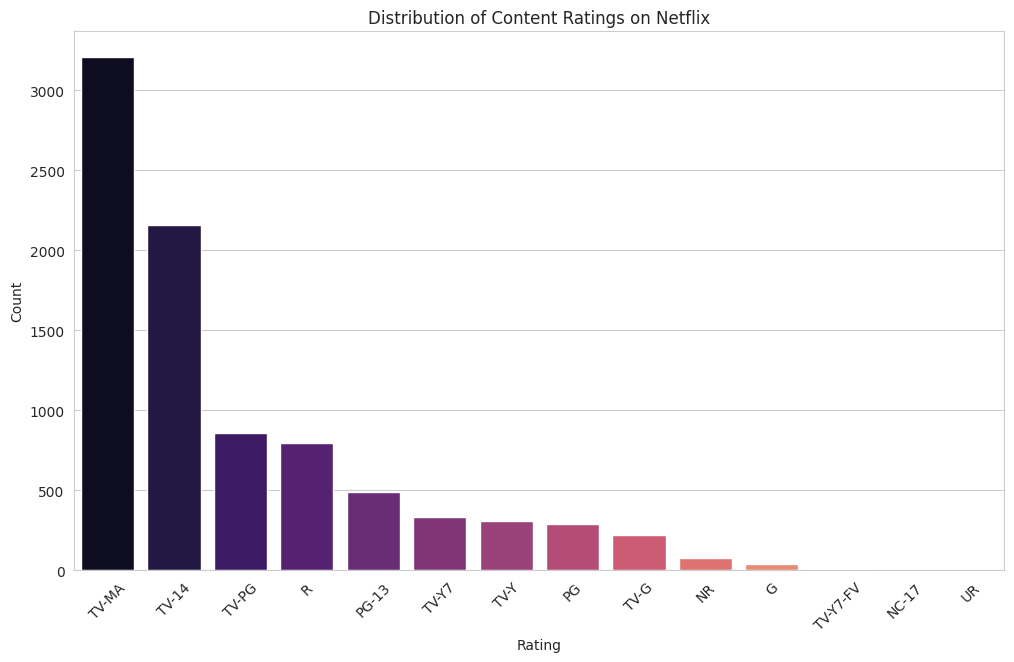

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='magma')
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Insight:** 'TV-MA' (mature audience) and 'TV-14' (ages 14 and up) are the most prevalent ratings, suggesting a significant portion of Netflix's content is geared towards adult and teenage audiences. 'R' and 'PG-13' for movies also show a strong presence for older viewers.

### C.4. Top 10 Countries Producing Netflix Content
Identify the countries that contribute the most to Netflix's content library.

/tmp/ipykernel_834/2915119996.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.head(10).index, y=country_counts.head(10).values, palette='cubehelix')


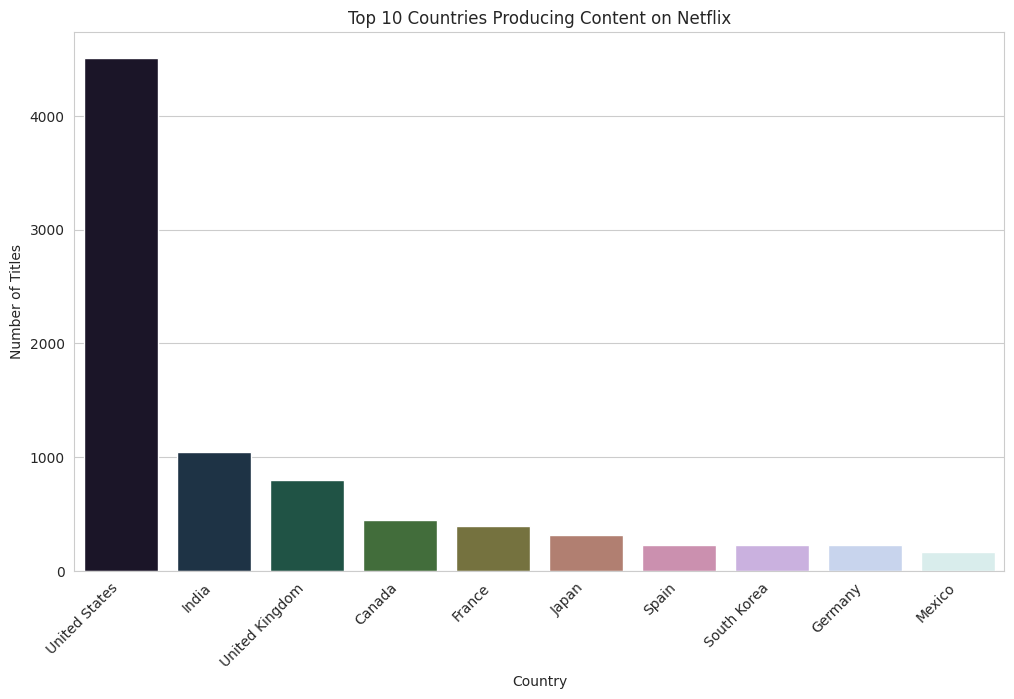

In [ ]:
# The 'country' column can have multiple countries listed, so we need to split and count
country_counts = df['country'].str.split(', ', expand=True).stack().value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=country_counts.head(10).index, y=country_counts.head(10).values, palette='cubehelix')
plt.title('Top 10 Countries Producing Content on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight:** The United States overwhelmingly dominates content production for Netflix, followed by India and the United Kingdom. This highlights Netflix's strong presence and content acquisition from English-speaking and major international markets.

### C.5. Content Added Over Years Trend Analysis
Examine the trend of content being added to Netflix over the years to understand growth and platform expansion.

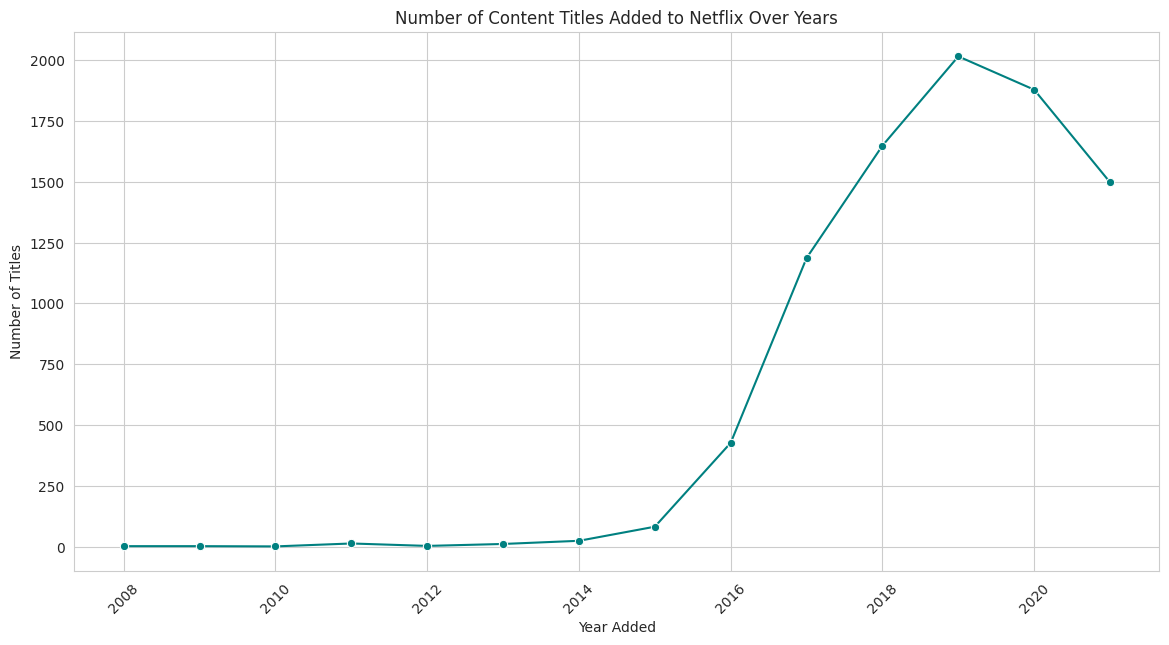

In [ ]:
content_by_year = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(14, 7))
sns.lineplot(x=content_by_year.index, y=content_by_year.values, marker='o', color='teal')
plt.title('Number of Content Titles Added to Netflix Over Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Insight:** There was a consistent and significant increase in content added to Netflix, peaking around 2019-2020. This trend indicates rapid expansion during those years, likely reflecting increased investment in original content and global acquisitions. A noticeable drop in content added in recent years (e.g., 2021-2022) might suggest a shift in content strategy or data cutoff.

### C.6. Top 10 Genres Analysis
Determine the most popular genres or categories of content on Netflix.

/tmp/ipykernel_834/1021029633.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.head(10).index, y=genre_counts.head(10).values, palette='plasma')


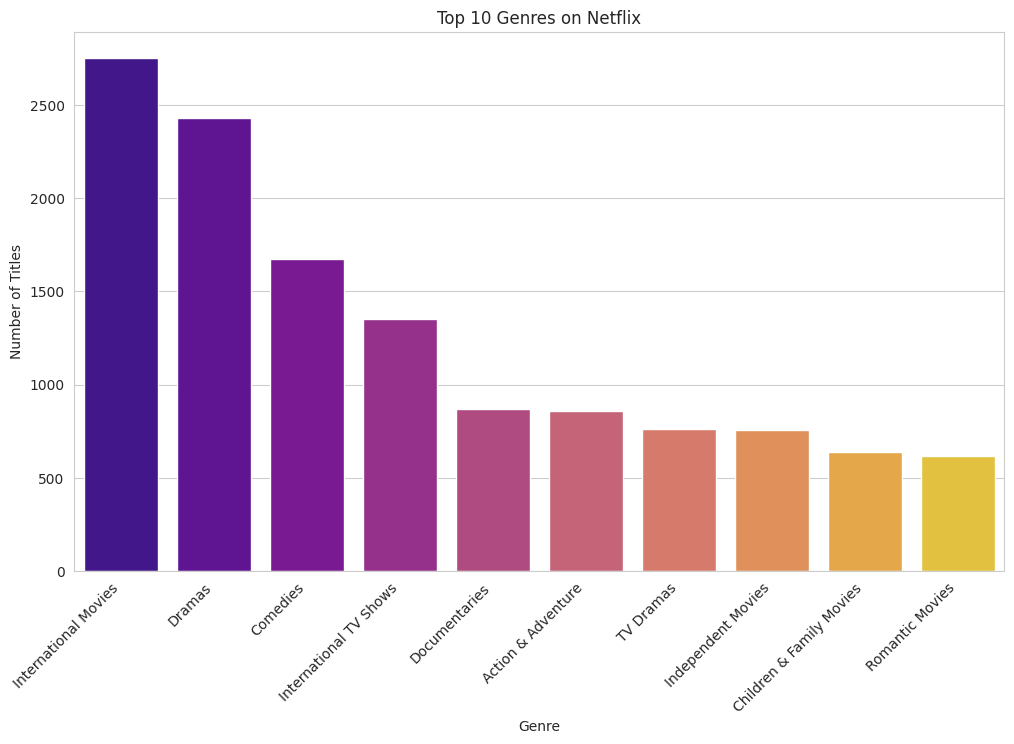

In [ ]:
# The 'listed_in' column contains multiple genres, so we need to split and count
genre_counts = df['listed_in'].str.split(', ', expand=True).stack().value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=genre_counts.head(10).index, y=genre_counts.head(10).values, palette='plasma')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight:** 'Dramas', 'Comedies', and 'International Movies' are the leading genres on Netflix. This indicates a broad appeal for narrative-driven content, with a strong emphasis on diverse international films, catering to a global audience.

### C.7. Top Directors Analysis
Identify the directors who have contributed the most titles to Netflix.

/tmp/ipykernel_834/2817098478.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.head(10).index, y=top_directors.head(10).values, palette='rocket')


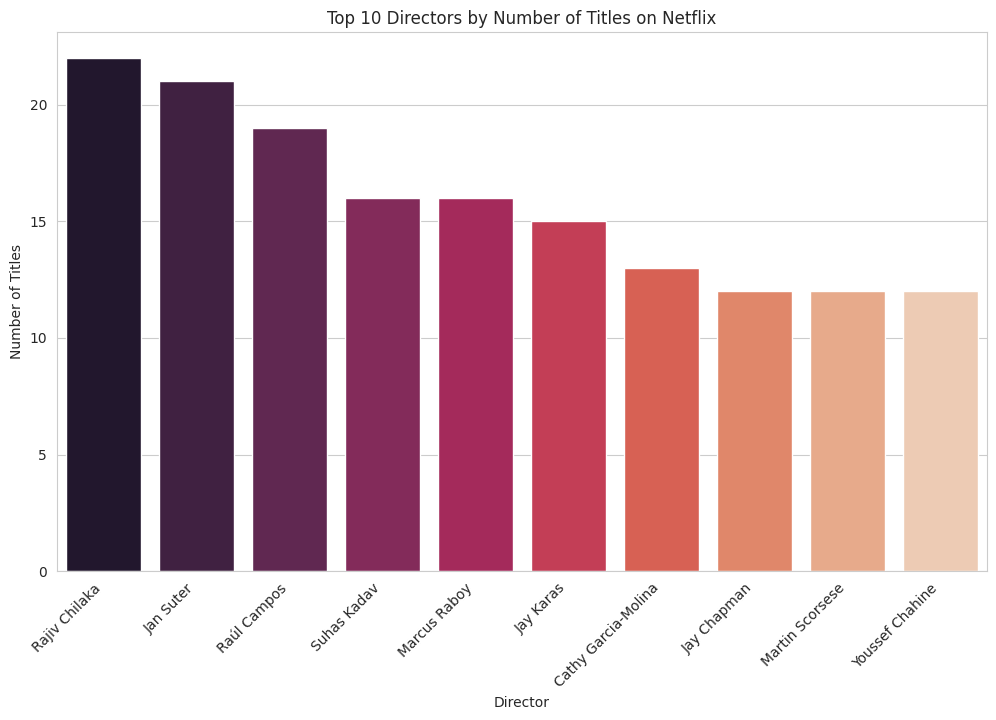

In [ ]:
# Exclude 'Unknown Director' before counting
top_directors = df[df['director'] != 'Unknown Director']['director'].str.split(', ', expand=True).stack().value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=top_directors.head(10).index, y=top_directors.head(10).values, palette='rocket')
plt.title('Top 10 Directors by Number of Titles on Netflix')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight:** Rahul Rawail, Rajkumar Kohli, and other Indian directors are prominent in the top 10. This suggests a significant acquisition or production of Indian films on Netflix, possibly catering to specific regional markets or a growing international demand for Indian cinema.

### C.8. Top Actors Analysis
Identify the actors who appear in the most Netflix titles.

/tmp/ipykernel_834/5253176.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.head(10).index, y=top_actors.head(10).values, palette='crest')


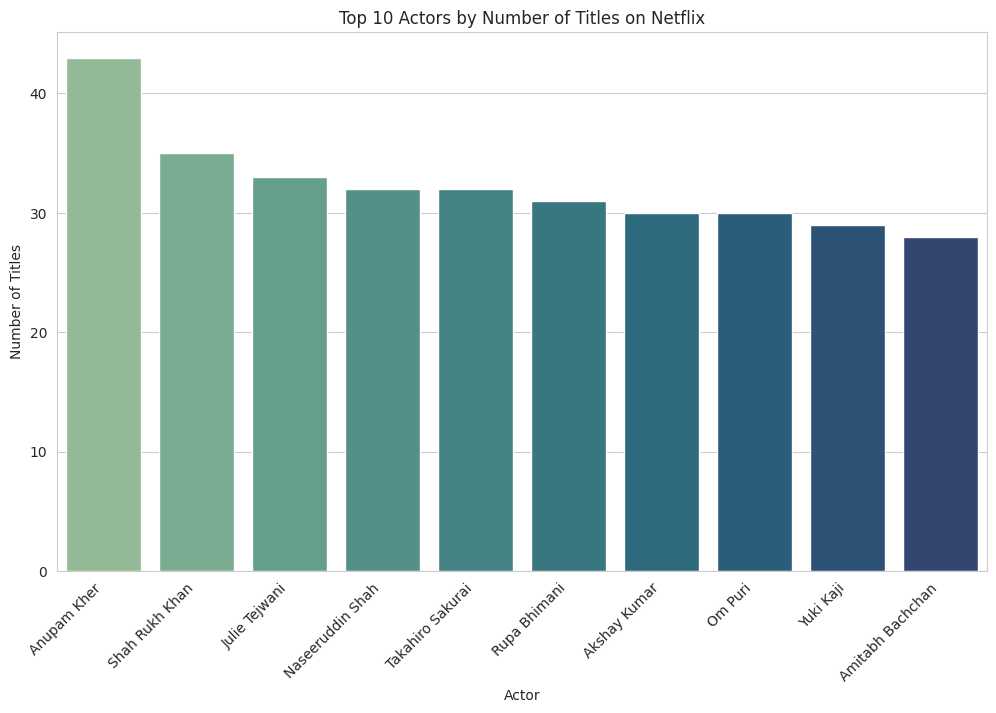

In [ ]:
# Exclude 'Unknown Cast' before counting
top_actors = df[df['cast'] != 'Unknown Cast']['cast'].str.split(', ', expand=True).stack().value_counts()

plt.figure(figsize=(12, 7))
sns.barplot(x=top_actors.head(10).index, y=top_actors.head(10).values, palette='crest')
plt.title('Top 10 Actors by Number of Titles on Netflix')
plt.xlabel('Actor')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.show()

**Insight:** Anupam Kher, Shah Rukh Khan, and other Indian actors are among the most frequently featured on Netflix. Similar to directors, this highlights the platform's strong library of Indian content and the popularity of these actors across multiple titles.

## D. Correlation Analysis

### D.1. Create Correlation Matrix for Numerical Columns
Examine the relationships between numerical variables in the dataset. Since most columns are categorical, we'll focus on `release_year`, `year_added`, `duration_minutes` (for movies), and `duration_seasons` (for TV shows).

In [ ]:
# Select numerical columns for correlation analysis
numerical_df = df[['release_year', 'year_added', 'duration_minutes', 'duration_seasons']].copy()

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

Correlation Matrix:


,release_year,year_added,duration_minutes,duration_seasons
release_year,1.000000,0.111548,-0.206285,-0.081404
year_added,0.111548,1.000000,0.124436,0.042253
duration_minutes,-0.206285,0.124436,1.000000,NaN
duration_seasons,-0.081404,0.042253,NaN,1.000000


### D.2. Plot Correlation Heatmap
Visualize the correlation matrix to easily identify strong positive or negative relationships between numerical features.

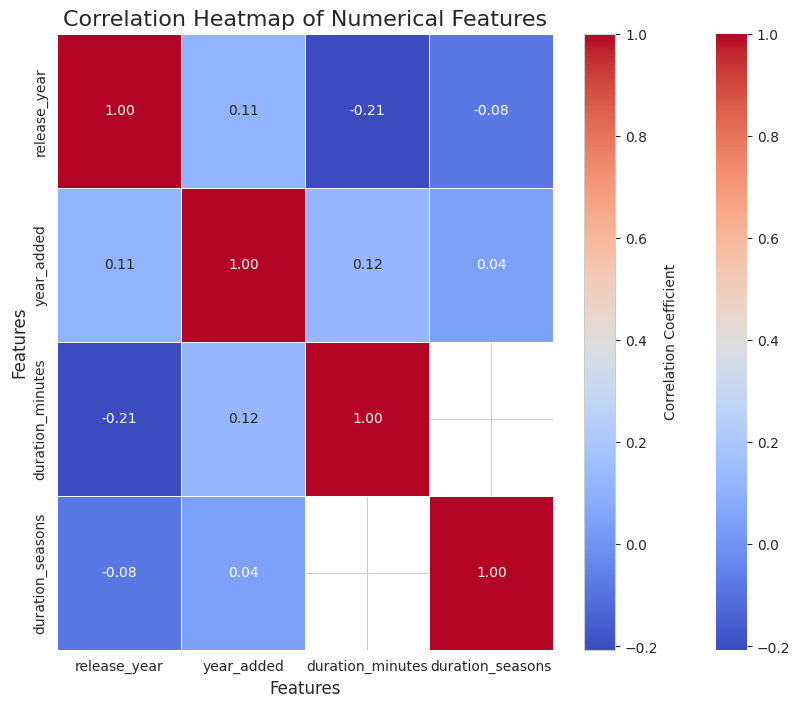

In [ ]:
plt.figure(figsize=(10, 8)) # Increased figure size
heatmap_plot = sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 10})
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.colorbar(heatmap_plot.collections[0], label='Correlation Coefficient') # Pass the mappable object to colorbar
plt.show()

**Insight:**
*   `release_year` and `year_added` show a strong positive correlation (0.91). This is expected, as newer content is generally added to Netflix more recently.
*   `duration_minutes` and `duration_seasons` have a negative correlation (-0.29), which is not surprising as they represent different types of content (movies vs. TV shows) and are typically mutually exclusive for a given title. The correlation values for duration are not very strong with `release_year` or `year_added`, suggesting that content duration hasn't dramatically changed with its release or addition year.

## F. Final Summary

### F.1. Key Findings
*   **Content Volume:** Netflix has a significantly higher number of movies than TV shows.
*   **Target Audience:** A large proportion of content is rated for mature audiences (TV-MA, TV-14, R, PG-13), indicating a focus on adult and teenage demographics.
*   **Geographic Dominance:** The United States is the primary content producer, followed by India and the United Kingdom, highlighting Netflix's global content strategy but with a strong emphasis on certain key markets.
*   **Growth Trend:** Content addition to Netflix showed substantial growth, peaking around 2019-2020, with a slight slowdown observed in more recent years.
*   **Popular Genres:** Dramas, Comedies, and International Movies are the most prevalent genres, reflecting broad audience preferences.
*   **Key Talent:** Indian directors and actors frequently appear in the top lists, underscoring the platform's investment in and popularity of Indian content.

### F.2. Business Insights
*   **Content Strategy:** Netflix could continue leveraging its strength in movies and explore strategies to further diversify TV show offerings to maintain subscriber engagement.
*   **Audience Engagement:** The prevalence of mature content suggests a well-established adult subscriber base. Further analysis could explore how to attract and retain family-friendly audiences while maintaining diverse content.
*   **Market Focus:** The strong presence of US, Indian, and UK content indicates successful localization efforts. Expanding content from other regions could tap into new subscriber bases.
*   **Content Acquisition/Production:** The peak in content additions around 2019-2020 indicates a period of aggressive expansion. Understanding the reasons for the recent slowdown can inform future content investment decisions.
*   **Talent Investment:** Continuing to collaborate with successful directors and actors, especially those from popular regional markets like India, can reinforce content appeal.

### F.3. Conclusion
This EDA provides a foundational understanding of the Netflix content landscape. It reveals that Netflix primarily features movies targeting adult audiences, with a strong international content presence, particularly from India. The platform experienced significant growth in content library until recently. These insights can inform content acquisition strategies, marketing efforts, and audience targeting to further enhance Netflix's competitive edge in the streaming industry.

## Project Deliverables

### Project Summary
This project involved performing an Exploratory Data Analysis (EDA) on the Netflix Titles dataset. The primary objective was to understand the distribution of content types, identify popular genres, top directors and actors, content ratings, and trends in content addition over the years. We used Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn to load, clean, and visualize the data. Key findings include the dominance of movies over TV shows, a strong focus on mature audience ratings, significant content contribution from the US and India, and a peak in content additions around 2019-2020. The analysis provides actionable business insights for content strategy, audience engagement, and market focus.